In [13]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os
import shutil
import requests
import math
from io import BytesIO

## Get Image from MapTiler API

In [14]:
def deg2num(lat, lon, zoom):
    """
    Umrechnung Lat/Lon → XYZ Tile‑Koordinaten
    """
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((1.0 - math.log(math.tan(lat_rad) +
                (1 / math.cos(lat_rad))) / math.pi) / 2.0 * n)
    return x, y

def fetch_tile(map_id, zoom, x, y, api_key):
    """
    Lädt eine einzelne Tile‑Kachel
    """
    url = f"https://api.maptiler.com/maps/{map_id}/256/{zoom}/{x}/{y}.png?key={api_key}"
    r = requests.get(url)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

def build_map(lat, lon, zoom, tiles_radius, api_key, map_id="satellite"):
    """
    Erstellt aus mehreren Tiles ein großes Bild
    """
    center_x, center_y = deg2num(lat, lon, zoom)

    size = 256 * (tiles_radius * 2 + 1)
    canvas = Image.new("RGB", (size, size))

    for dx in range(-tiles_radius, tiles_radius + 1):
        for dy in range(-tiles_radius, tiles_radius + 1):
            x = center_x + dx
            y = center_y + dy
            tile = fetch_tile(map_id, zoom, x, y, api_key)
            px = (dx + tiles_radius) * 256
            py = (dy + tiles_radius) * 256
            canvas.paste(tile, (px, py))

    return canvas

In [15]:
api_key = "qR5z0FXl7vgm9kk146HC"

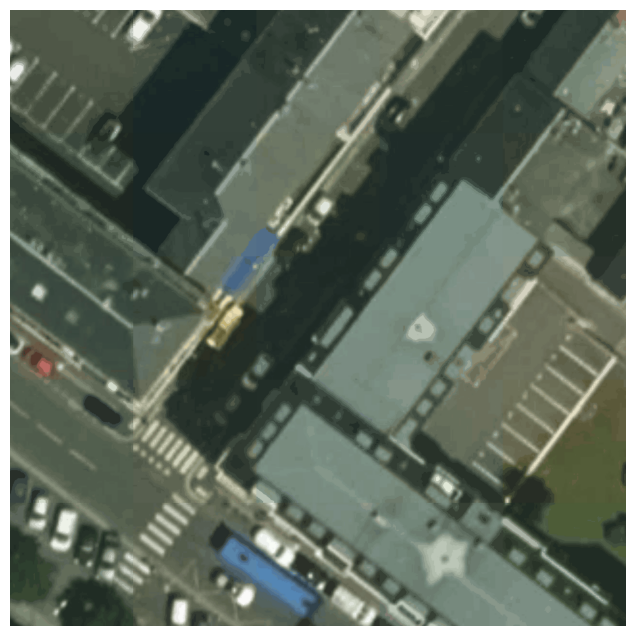

In [16]:
if __name__ == "__main__":

    # lat, lon = 49.182206, -0.359821   # good example
    lat, lon = 49.186597, -0.355784     # ex2 mit coords mehr auf Kreuzung ergibt conf=0.4 für segmentierung???
    lat, lon = 49.186570, -0.355924
    # lat, lon = 49.186358, -0.372618     # meh example
    lat, lon = 49.183615, -0.354067
    
    
    img_name = "test_UP+RIGHT"

    # number of tiles around center-coords
    tiles_radius = 2
    zoom = 21       # Std = 21


    map_img = build_map(lat, lon, zoom, tiles_radius, api_key)
    map_img.save(f"{img_name}.png")
    
    plt.figure(figsize=(8,8))
    plt.imshow(map_img)
    plt.axis('off')
    plt.show()

## Segmentation

In [17]:
def predict_intersection(save_dir, image_path, model_path="yolov11n-seg.pt"):    

    # load model
    model = YOLO(model_path)

    # segment image (prediction)
    results = model.predict(
        source=image_path,
        imgsz=512,     
        device=0,      # GPU; für CPU device="cpu"
        conf=0.2,      # Confidence
        save=True,
        project=f"{save_dir}",
        save_txt=True,
    )

    # get resulting image
    result_img = results[0].plot()  # returns rgb image of np.array from result object

    # visualize
    plt.figure(figsize=(8,8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.show()

    return results


image 1/1 c:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\test_UP+RIGHT.png: 512x512 1 intersection, 14.6ms
Speed: 1.8ms preprocess, 14.6ms inference, 6.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to C:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\predictions\test_UP+RIGHT\predict
1 label saved to C:\Users\David\Desktop\HTWD\AAI\Project\testing\dataset_caen\yolo\dataset\predictions\test_UP+RIGHT\predict\labels


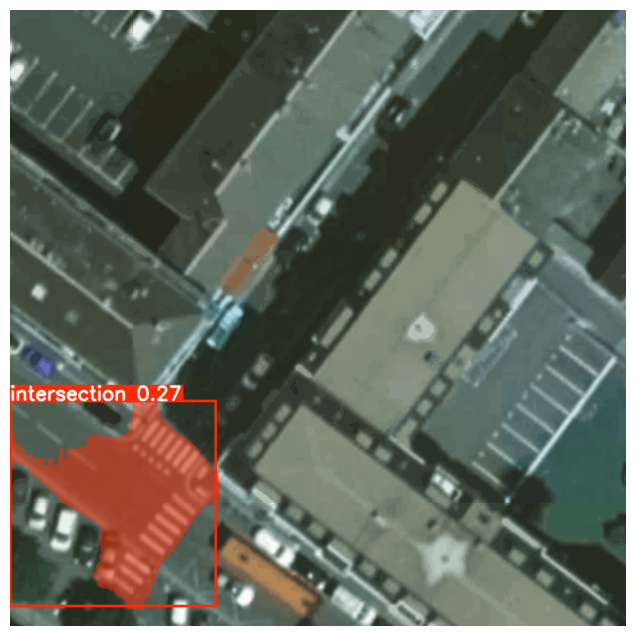

In [18]:
os.makedirs("predictions", exist_ok=True)


save_dir = f"predictions/{img_name}"    # save in predictions-folder for each image processed
os.makedirs(save_dir, exist_ok=True)
if save_dir:
    shutil.rmtree(save_dir)     # deletes previous results


results = predict_intersection(
    save_dir=save_dir,
    image_path= f"{img_name}.png",
    model_path="runs/segment/train/weights/best.pt",    # Path to YOLO-model
)